# EDA — myPersonality Dataset (`wcpr_mypersonality.csv`)

Exploratory analysis of the Facebook status-update dataset paired with Big Five personality scores.

| Column | Description |
|--------|-------------|
| `#AUTHID` | Anonymised author ID |
| `STATUS` | Facebook status text |
| `sEXT/sNEU/sAGR/sCON/sOPN` | Continuous Big Five scores |
| `cEXT/cNEU/cAGR/cCON/cOPN` | Binary labels — `y` (high) / `n` (low) |
| `DATE` | Post timestamp |
| Network metrics | `NETWORKSIZE`, `BETWEENNESS`, … |

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

RAW_PATH = Path('../../data/raw/wcpr_mypersonality.csv')

df = pd.read_csv(RAW_PATH, encoding='latin-1')
df.rename(columns={'#AUTHID': 'author_id'}, inplace=True)
df['DATE'] = pd.to_datetime(df['DATE'], format='%m/%d/%y %I:%M %p', errors='coerce')
df['word_count'] = df['STATUS'].fillna('').apply(lambda x: len(str(x).split()))
df['char_count'] = df['STATUS'].fillna('').apply(len)

print(f"Shape  : {df.shape}")
print(f"Authors: {df['author_id'].nunique()}")
df.head(3)

Shape  : (9917, 22)
Authors: 250


,author_id,STATUS,sEXT,sNEU,sAGR,sCON,sOPN,cEXT,cNEU,cAGR,...,DATE,NETWORKSIZE,BETWEENNESS,NBETWEENNESS,DENSITY,BROKERAGE,NBROKERAGE,TRANSITIVITY,word_count,char_count
0,b7b7764cfa1c523e4e93ab2a79a946c4,likes the sound of thunder.,2.65,3.0,3.15,3.25,4.4,n,y,n,...,2009-06-19 15:21:00,180.0,14861.6,93.29,0.03,15661.0,0.49,0.1,5,27
1,b7b7764cfa1c523e4e93ab2a79a946c4,is so sleepy it's not even funny that's she ca...,2.65,3.0,3.15,3.25,4.4,n,y,n,...,2009-07-02 08:41:00,180.0,14861.6,93.29,0.03,15661.0,0.49,0.1,13,63
2,b7b7764cfa1c523e4e93ab2a79a946c4,is sore and wants the knot of muscles at the b...,2.65,3.0,3.15,3.25,4.4,n,y,n,...,2009-06-15 13:15:00,180.0,14861.6,93.29,0.03,15661.0,0.49,0.1,26,121


## 2. Dataset Overview

In [2]:
print("=== Missing Values ===")
print(df.isnull().sum()[df.isnull().sum() > 0])
print()
print(f"Total posts    : {len(df):,}")
print(f"Unique authors : {df['author_id'].nunique():,}")
print(f"Date range     : {df['DATE'].min()} → {df['DATE'].max()}")

=== Missing Values ===
DATE            1
TRANSITIVITY    1
dtype: int64

Total posts    : 9,917
Unique authors : 250
Date range     : 2009-01-01 00:12:00 → 2011-02-27 09:59:00


## 3. Posts per Author

count    250.00
mean      39.67
std       43.56
min        1.00
25%        8.00
50%       25.00
75%       54.75
max      223.00
Name: post_count, dtype: float64


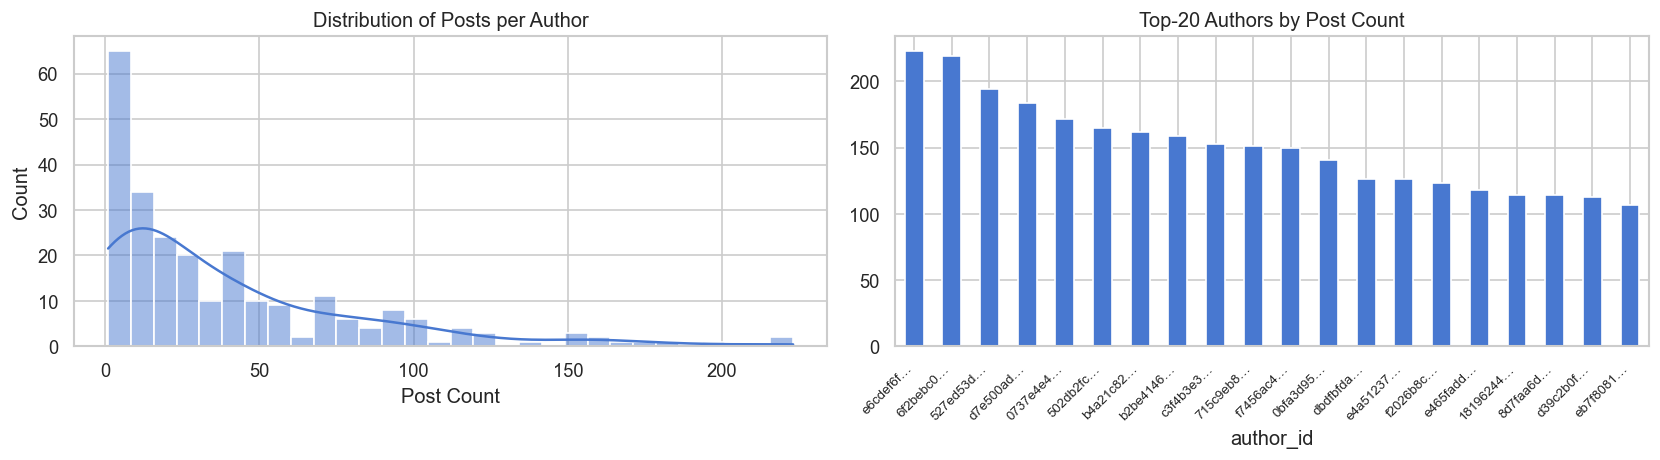

In [3]:
posts_per_author = df.groupby('author_id').size().rename('post_count')
print(posts_per_author.describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(posts_per_author, bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Posts per Author')
axes[0].set_xlabel('Post Count')

top20 = posts_per_author.sort_values(ascending=False).head(20)
top20.plot(kind='bar', ax=axes[1], color=sns.color_palette('muted')[0])
axes[1].set_title('Top-20 Authors by Post Count')
axes[1].set_xticklabels([x[:8]+'…' for x in top20.index], rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

## 4. Word-Count Distribution

count    9917.00
mean       14.53
std        12.46
min         1.00
25%         6.00
50%        11.00
75%        19.00
max        89.00
Name: word_count, dtype: float64


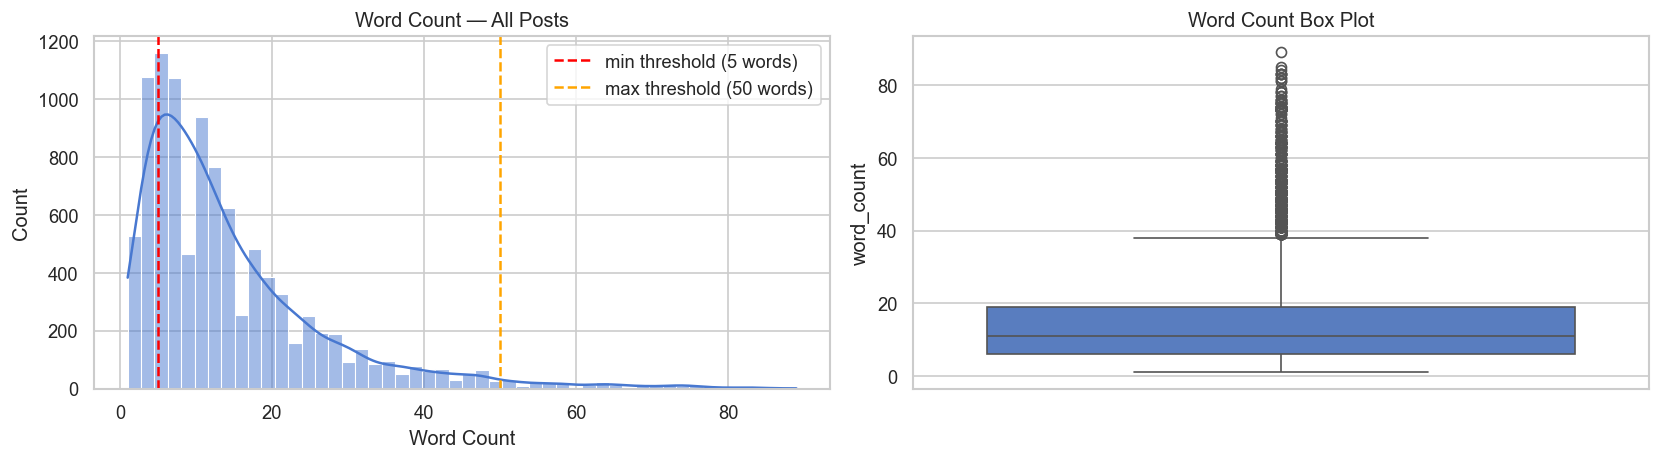

Too short (< 5)  : 1,604  (16.2%)
Too long  (> 50) : 224   (2.3%)
In range  [5–50] : 8,089  (81.6%)


In [4]:
print(df['word_count'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df['word_count'], bins=50, kde=True, ax=axes[0])
axes[0].axvline(5,  color='red',    linestyle='--', label='min threshold (5 words)')
axes[0].axvline(50, color='orange', linestyle='--', label='max threshold (50 words)')
axes[0].set_title('Word Count — All Posts')
axes[0].set_xlabel('Word Count')
axes[0].legend()

sns.boxplot(y=df['word_count'], ax=axes[1])
axes[1].set_title('Word Count Box Plot')

plt.tight_layout()
plt.show()

too_short = (df['word_count'] <  5).sum()
too_long  = (df['word_count'] > 50).sum()
in_range  = ((df['word_count'] >= 5) & (df['word_count'] <= 50)).sum()
print(f"Too short (< 5)  : {too_short:,}  ({too_short/len(df)*100:.1f}%)")
print(f"Too long  (> 50) : {too_long:,}   ({too_long/len(df)*100:.1f}%)")
print(f"In range  [5–50] : {in_range:,}  ({in_range/len(df)*100:.1f}%)")

## 5. Personality Score Distributions

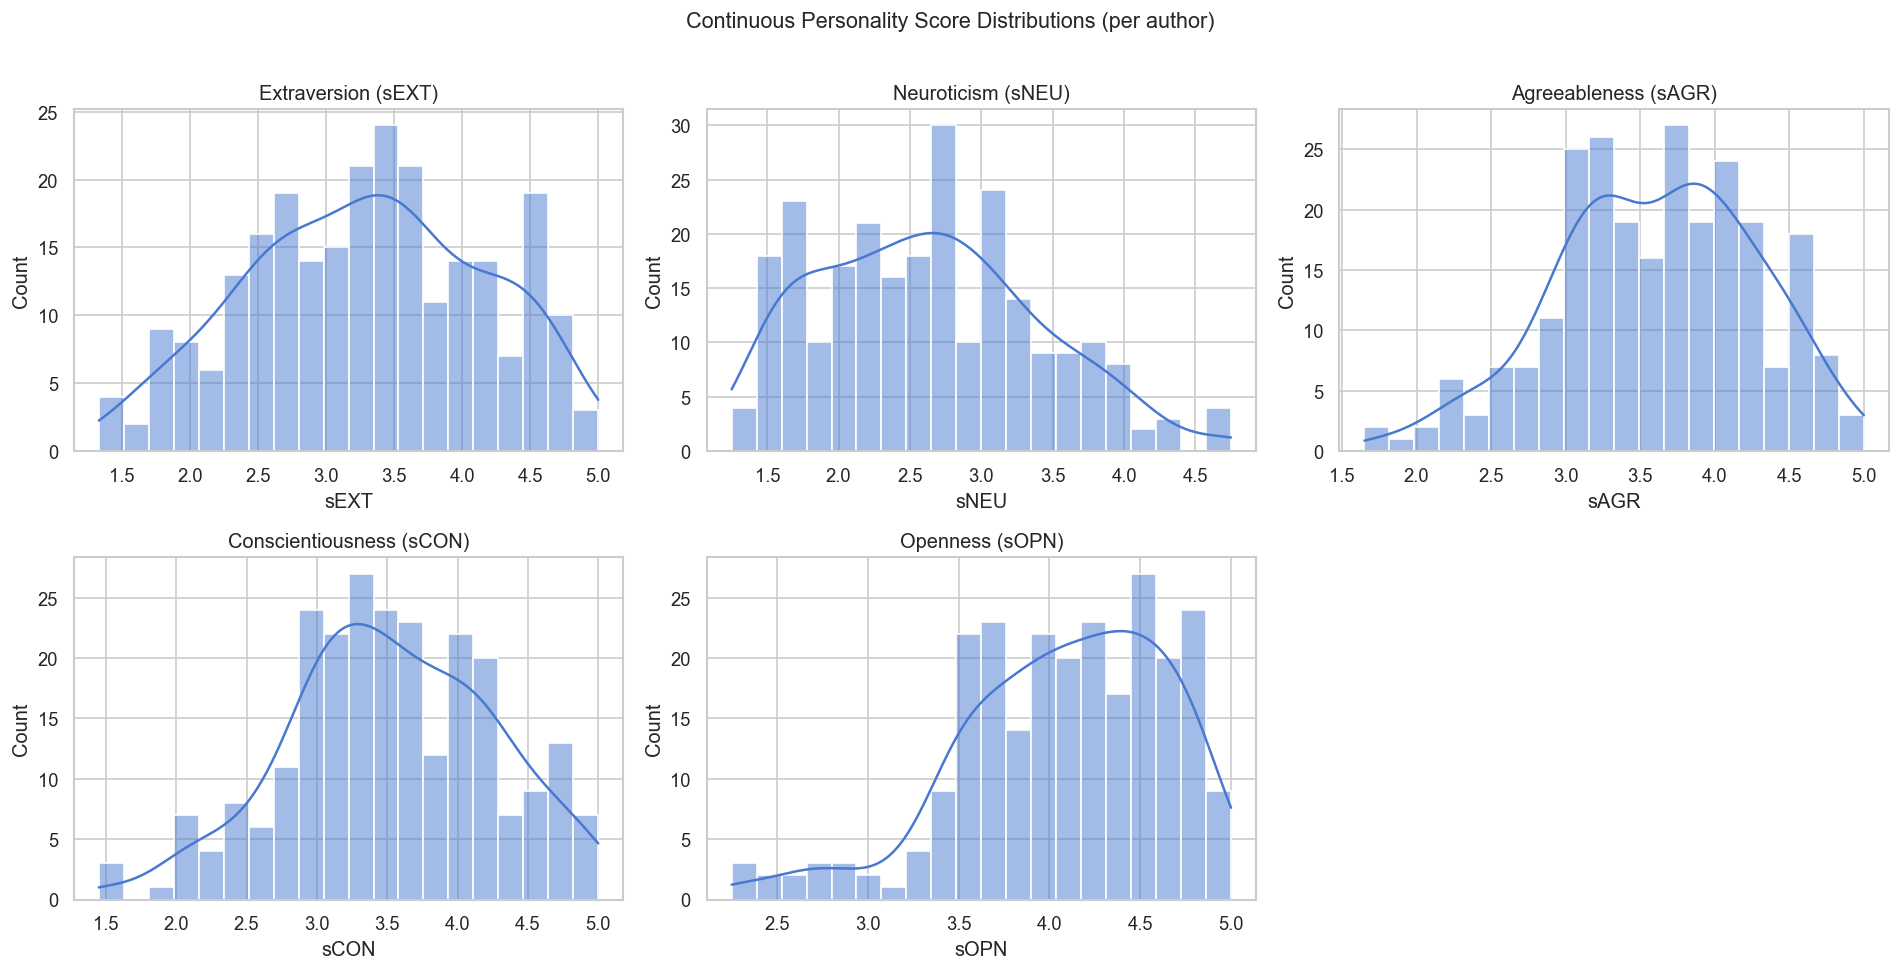

         sEXT    sNEU    sAGR    sCON    sOPN
count  250.00  250.00  250.00  250.00  250.00
mean     3.29    2.63    3.60    3.52    4.08
std      0.86    0.78    0.67    0.74    0.58
min      1.33    1.25    1.65    1.45    2.25
25%      2.66    2.00    3.15    3.00    3.75
50%      3.30    2.59    3.66    3.50    4.15
75%      4.00    3.15    4.10    4.05    4.50
max      5.00    4.75    5.00    5.00    5.00


In [5]:
score_cols  = ['sEXT', 'sNEU', 'sAGR', 'sCON', 'sOPN']
trait_names = ['Extraversion', 'Neuroticism', 'Agreeableness', 'Conscientiousness', 'Openness']

author_df = df.groupby('author_id')[score_cols].first().reset_index()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, (col, label) in enumerate(zip(score_cols, trait_names)):
    sns.histplot(author_df[col], bins=20, kde=True, ax=axes[i])
    axes[i].set_title(f'{label} ({col})')
axes[-1].set_visible(False)
plt.suptitle('Continuous Personality Score Distributions (per author)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
print(author_df[score_cols].describe().round(2))

## 6. Binary Label Balance

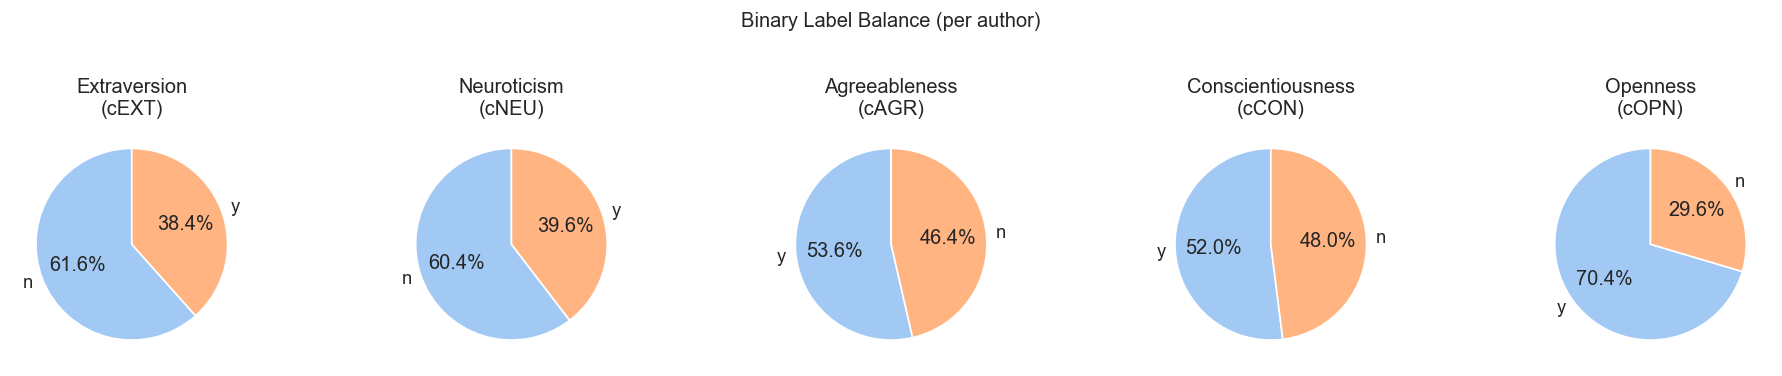

In [6]:
label_cols = ['cEXT', 'cNEU', 'cAGR', 'cCON', 'cOPN']
author_class = df.groupby('author_id')[label_cols].first().reset_index()

fig, axes = plt.subplots(1, 5, figsize=(16, 3))
for ax, col, name in zip(axes, label_cols, trait_names):
    counts = author_class[col].value_counts()
    ax.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
           startangle=90, colors=sns.color_palette('pastel')[:2])
    ax.set_title(f'{name}\n({col})')
plt.suptitle('Binary Label Balance (per author)', fontsize=12, y=1.04)
plt.tight_layout()
plt.show()

## 7. Score Correlation Matrix

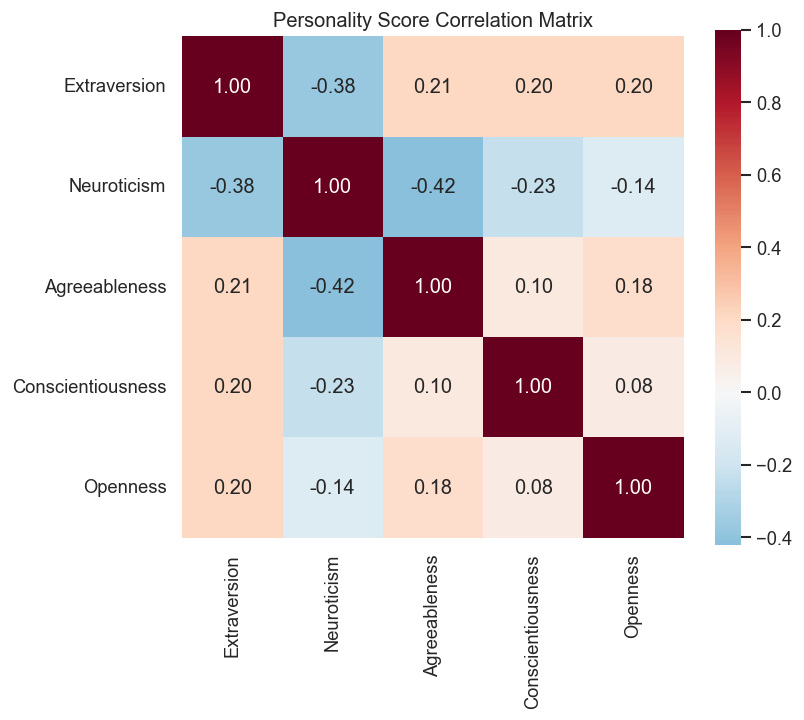

In [7]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(author_df[score_cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, ax=ax,
            xticklabels=trait_names, yticklabels=trait_names)
ax.set_title('Personality Score Correlation Matrix')
plt.tight_layout()
plt.show()

## 8. Word Count vs Personality Scores

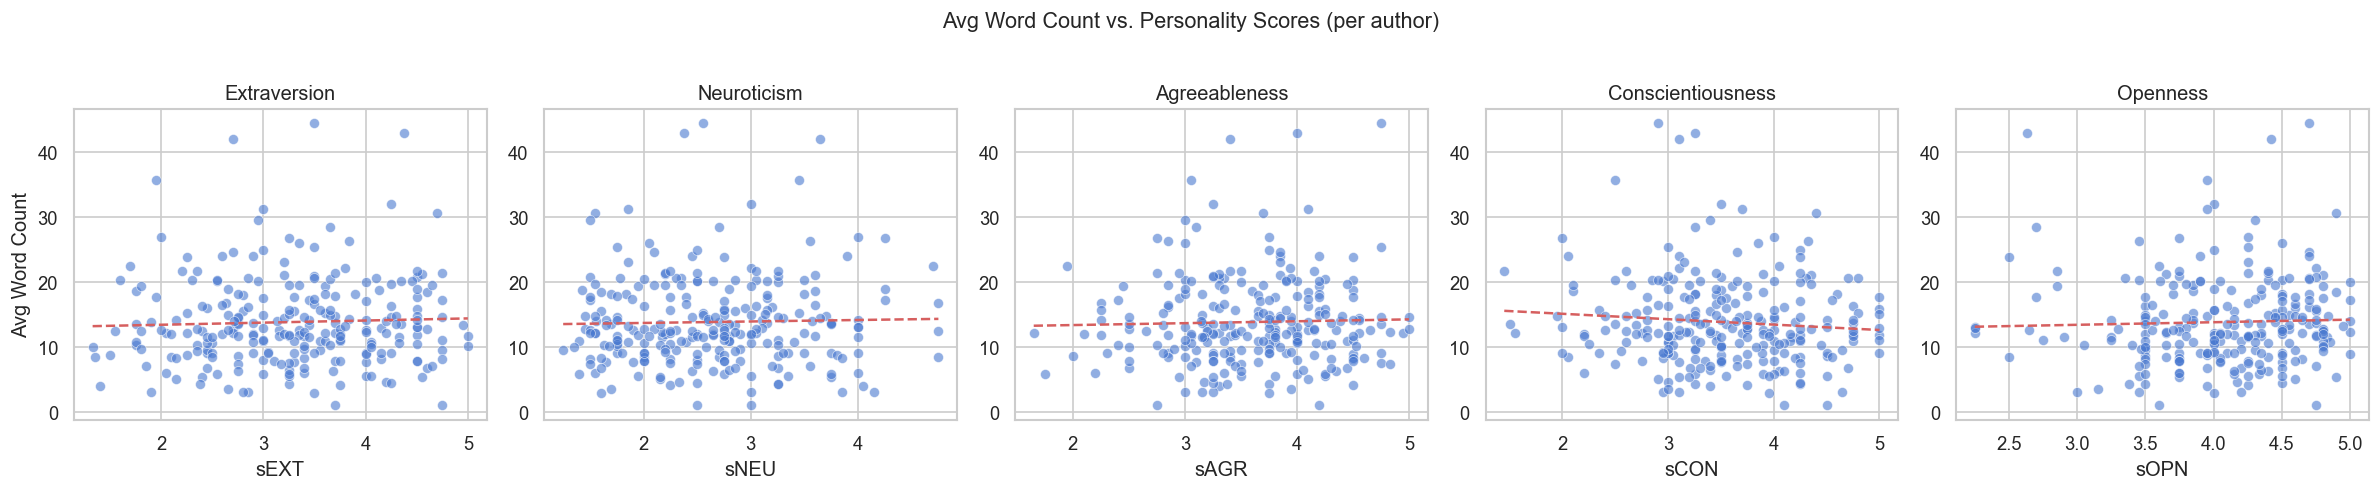

In [8]:
avg_wc = df.groupby('author_id')['word_count'].mean().rename('avg_word_count')
merged = author_df.set_index('author_id').join(avg_wc)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, (col, label) in enumerate(zip(score_cols, trait_names)):
    sns.scatterplot(data=merged, x=col, y='avg_word_count', alpha=0.6, ax=axes[i])
    z = np.polyfit(merged[col].dropna(), merged.loc[merged[col].notna(), 'avg_word_count'], 1)
    xs = np.linspace(merged[col].min(), merged[col].max(), 100)
    axes[i].plot(xs, np.poly1d(z)(xs), 'r--', linewidth=1.5)
    axes[i].set_title(label)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Avg Word Count' if i == 0 else '')
plt.suptitle('Avg Word Count vs. Personality Scores (per author)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 9. Temporal Analysis

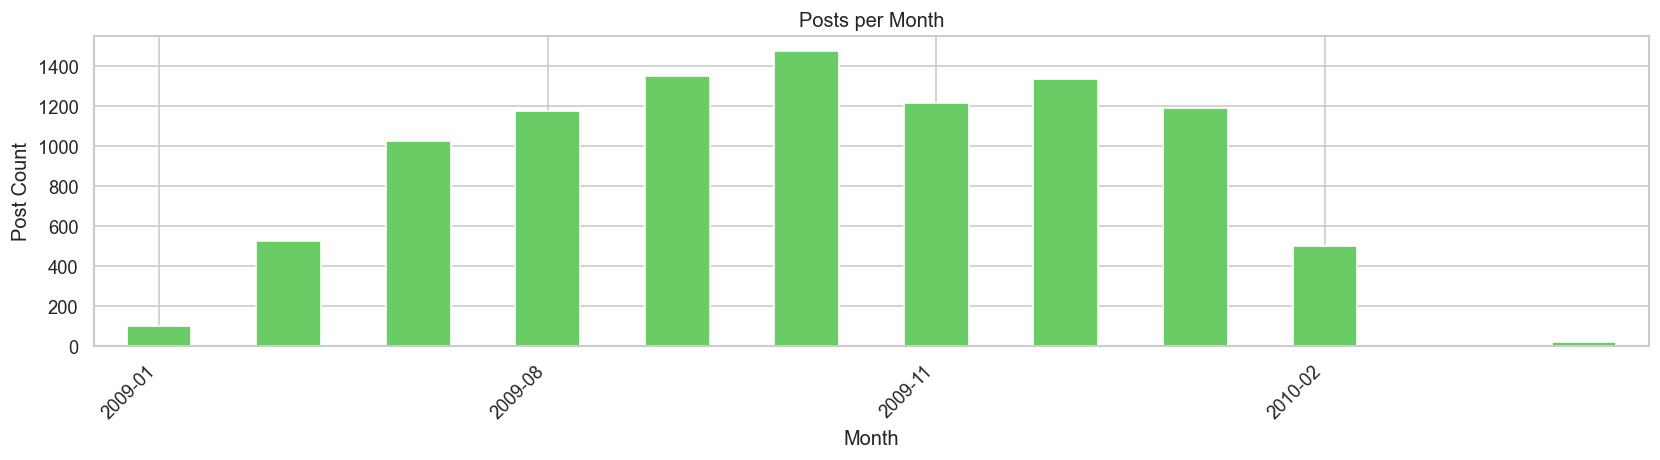

In [9]:
df_dated = df.dropna(subset=['DATE']).copy()
df_dated['year_month'] = df_dated['DATE'].dt.to_period('M')
monthly = df_dated.groupby('year_month').size()

fig, ax = plt.subplots(figsize=(14, 4))
monthly.plot(kind='bar', ax=ax, color=sns.color_palette('muted')[2])
ax.set_title('Posts per Month')
ax.set_xlabel('Month')
ax.set_ylabel('Post Count')
ax.xaxis.set_major_locator(mticker.MultipleLocator(3))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 10. Network Metrics

       NETWORKSIZE  BETWEENNESS  NBETWEENNESS  DENSITY    BROKERAGE  \
count      250.000      250.000       250.000  250.000      250.000   
mean       408.012   128936.802        93.981    0.034   131342.232   
std        316.636   204807.609         7.080    0.036   207014.930   
min         24.000      185.710        31.210    0.000      241.000   
25%        175.000    14062.350        93.260    0.010    14576.250   
50%        315.000    46636.100        96.020    0.020    48358.000   
75%        556.500   145483.000        97.808    0.040   152115.750   
max       1596.000  1251780.000        99.820    0.400  1263790.000   

       NBROKERAGE  TRANSITIVITY  
count     250.000       250.000  
mean        0.488         0.139  
std         0.016         0.113  
min         0.320         0.000  
25%         0.490         0.060  
50%         0.490         0.110  
75%         0.500         0.180  
max         0.500         0.630  


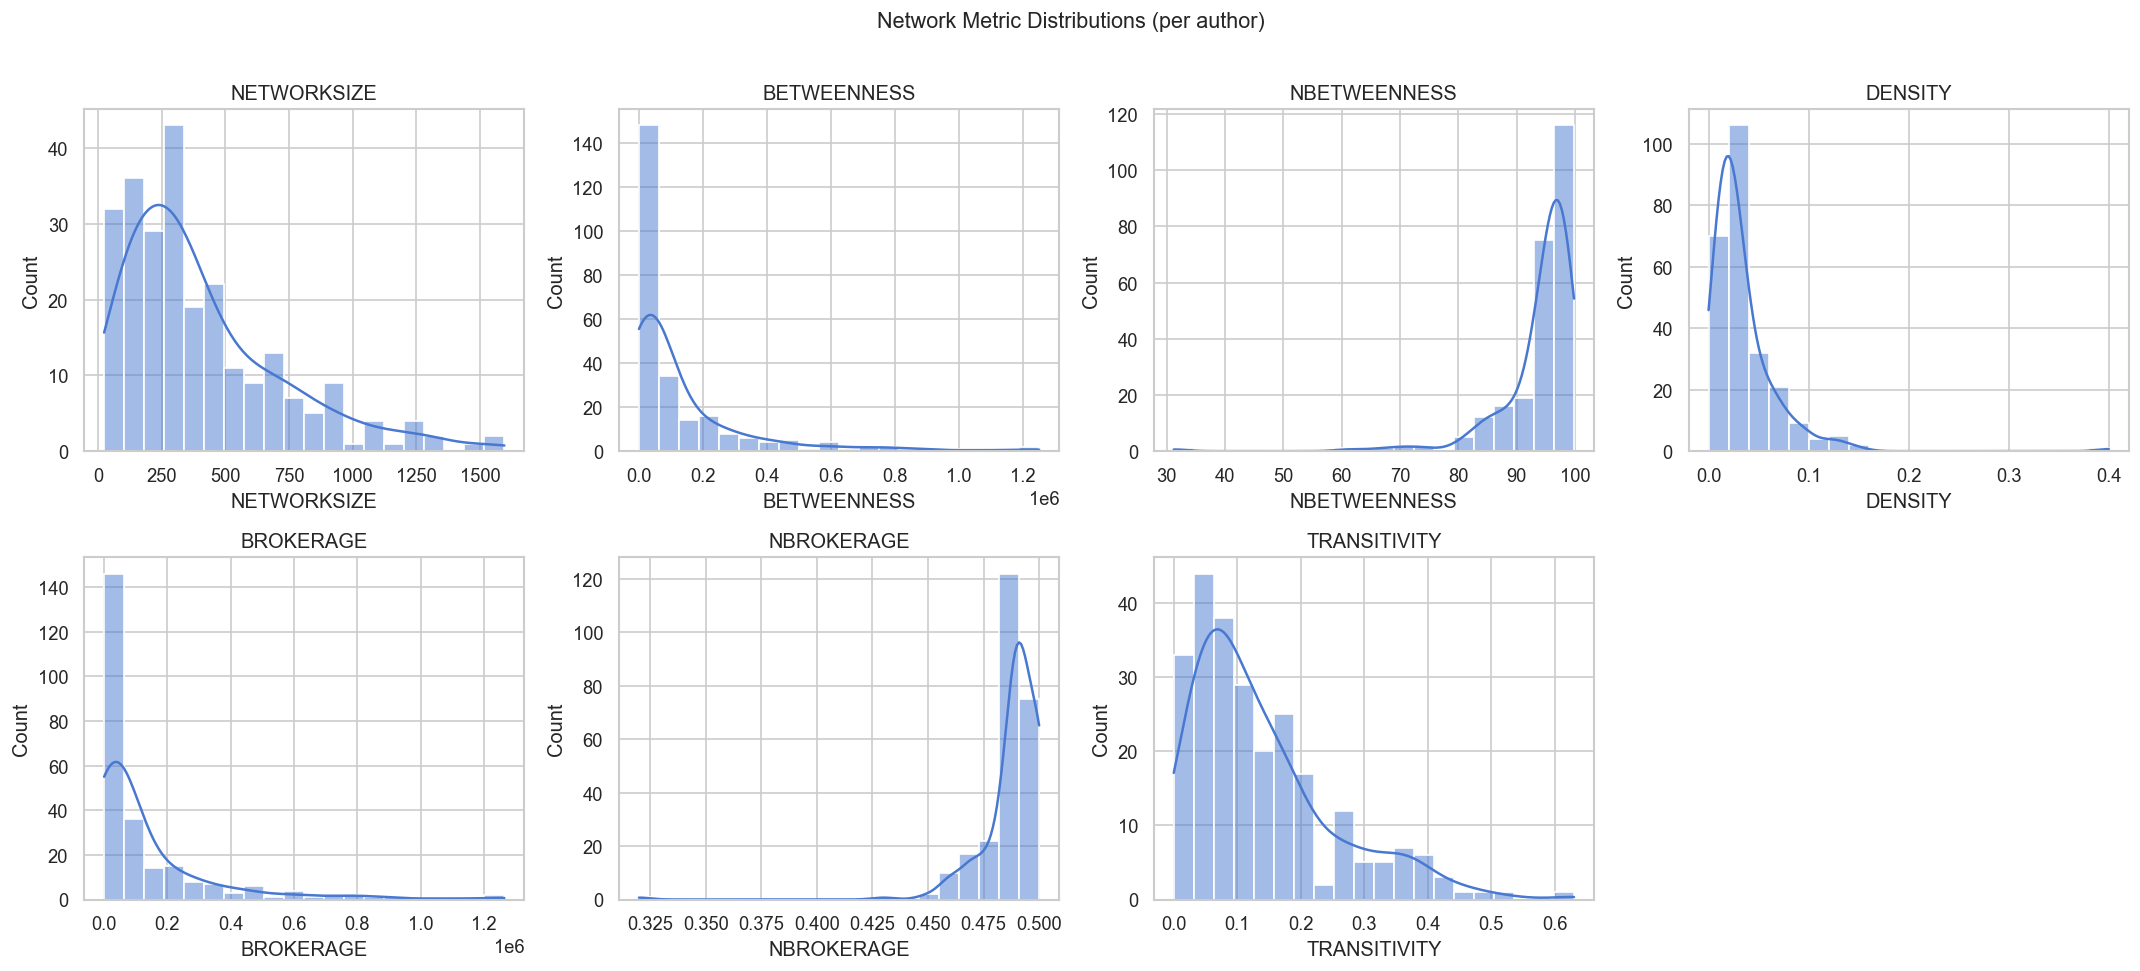

In [10]:
net_cols = ['NETWORKSIZE','BETWEENNESS','NBETWEENNESS','DENSITY','BROKERAGE','NBROKERAGE','TRANSITIVITY']
author_net = df.groupby('author_id')[net_cols].first()
print(author_net.describe().round(3))

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(net_cols):
    sns.histplot(author_net[col].dropna(), bins=20, kde=True, ax=axes[i])
    axes[i].set_title(col)
axes[-1].set_visible(False)
plt.suptitle('Network Metric Distributions (per author)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Summary

- **9,917 posts** from **250 authors** (median 25 posts/author, max 223)
- Typical post: **14.5 words**; applying [5, 50] word filter retains ~82% of posts
- Personality labels are reasonably balanced across all five traits
- Data collected mainly **2009–2011**

→ See `process_mypersonality.ipynb` for the full processing and split pipeline.